# Packing puzzles, part 2: IQpuzzler and IQpuzzlerPRO

`1_solver.ipynb` built a solver for packing puzzles. This notebook puts it to use on two real games: *IQpuzzler*, and
its revamped sequel *IQpuzzlerPRO*, whose box promises that every one of its puzzles has exactly one solution. Along
the way it asks how few or how many solutions a puzzle could have at all.

Almost everything is computed when you run it. The one exception is the bounds in section 2, which take a couple of
minutes to compute, so they are loaded from `bounds/`.

*Some outputs are long. VS Code cuts cell outputs at 30 lines by default; to see them in full, raise
`notebook.output.textLineLimit` (to 200, say) in your settings.
GitHub and JupyterLab show outputs in full.*

In [1]:
import matplotlib.pyplot as plt

from pugpuzzler.constants import GAMES_DIR

from pugpuzzler.plotting.plot_bounds import plot_bounds
from pugpuzzler.plotting.plot_puzzle_stats import plot_puzzle_stats
from pugpuzzler.plotting.plot_solve_timeline import plot_solve_timeline
from pugpuzzler.puzzle_bounds import compute_puzzle_bounds
from pugpuzzler.serialization import load_bounds, load_game, save_bounds
from pugpuzzler.solving import Verbosity, solve_puzzle, solve_puzzlebook

IQpuzzler = load_game(GAMES_DIR / "IQpuzzler")
IQpuzzlerPRO = load_game(GAMES_DIR / "IQpuzzlerPRO")

# Part I: IQpuzzler

[IQpuzzler](https://www.smartgames.eu/) is a packing puzzle originally developed by *Lonpos*, and later distributed by
*Smartgames*.
<div>
<img src="images/IQpuzzler_main.png" width="300"/>
</div>

It contains the 12 pieces and the 55-cell board of `1_solver`, and a booklet of 72 puzzles that each fix a few pieces in
place and ask you to fit in the rest. A second booklet of 29 puzzles stacks the same pieces into a pyramid; it comes
back in Part II.

## 1. The booklet

The booklet's puzzles come in five difficulty tiers, from *starter* to *wizard*. Let's solve all of them and find
**every** solution of each, not just the first.

In [2]:
main_puzzles = IQpuzzler.books["main_puzzles"]
main_solutions, main_stats = solve_puzzlebook(main_puzzles)

counts = {name: len(sol) for name, sol in main_solutions.items()}
unique = [name for name, n in counts.items() if n == 1]
most = max(counts, key=counts.get)
print(f"Solved {len(counts)} puzzles in {sum(s.duration for s in main_stats.values()):.2f} s.")
print(f"{len(unique)} have a unique solution; {len(counts) - len(unique)} have more than one.")
print(f"Puzzle {most} ({main_puzzles[most].difficulty}) has {counts[most]} solutions.")

Solved 72 puzzles in 1.13 s.
29 have a unique solution; 43 have more than one.
Puzzle 57 (master) has 1209 solutions.


Most of the booklet's puzzles have more than one solution. The timeline shows each puzzle as a column, with one mark for
every solution at the moment it was found. The printed difficulty shows up here too: the solver needs ~0.1 ms for a
*starter* and ~10 ms for a *master* or *wizard*, and the puzzles with hundreds of solutions are easy to spot:

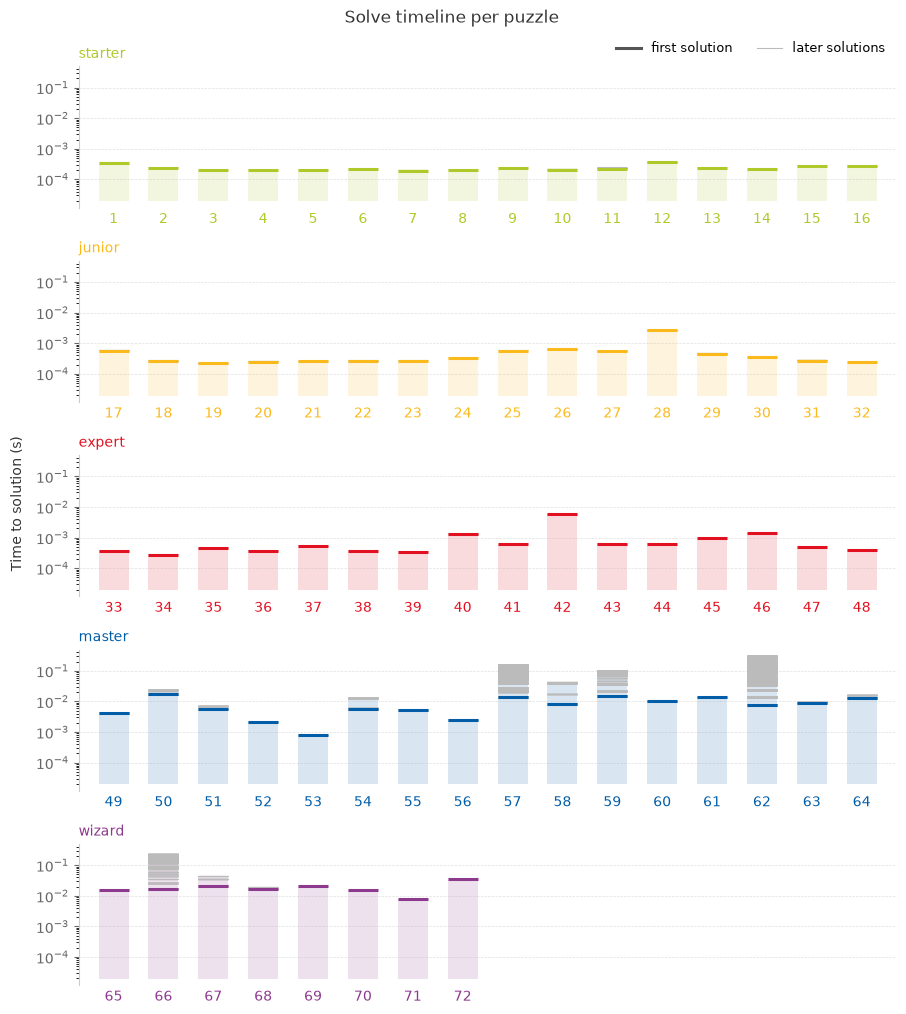

In [3]:
plot_solve_timeline(main_puzzles, main_stats)
plt.show()

The more pieces a puzzle places for you, the fewer ways are left to finish it. Plotting the number of solutions
against the number of pre-filled cells shows how the tiers are built: *starter* puzzles leave one or two pieces to
place, *wizard* puzzles nine of the twelve. Within a tier, though, the number of solutions varies a lot.

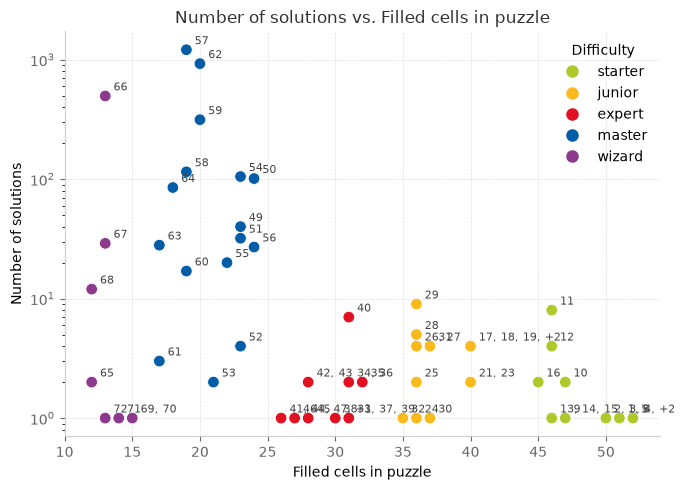

In [4]:
plot_puzzle_stats(main_puzzles, main_stats)
plt.show()

That raises the question this part is about: **how far could it go?** With a given number of pre-filled cells, how few
solutions can a puzzle have, and how many? Are there puzzles harder than the booklet's *wizards*, or unique ones with
even fewer pieces given?

## 2. The bounds

The answer comes from the **empty board**. Any puzzle is "some blocks fixed in place", and every solution of that
puzzle is also a solution of the empty board, one that happens to place those blocks the same way. So once we have
every solution of the empty board, the number of solutions of *any* puzzle is a count: how many empty-board solutions
agree with it on the fixed blocks.

`compute_puzzle_bounds` does exactly that. It groups the empty board's solutions by how they place each subset of
blocks, without calling the solver again. For every number of filled cells, it finds the puzzle with the fewest
solutions (the **lower bound**) and the one with the most (the **upper bound**). These are exact, not samples.

The bounds themselves are small, and they are part of the repository under `bounds/`, so we just load them:

In [5]:
(lower_puzzles, lower_stats), (upper_puzzles, upper_stats) = load_bounds(IQpuzzler, "main")

empty_stats = lower_stats["1"]   # each bound book starts at the empty board itself
print(f"The empty board has {len(empty_stats.elapsed):,} solutions (found in {empty_stats.duration:.1f} s).")

The empty board has 371,020 solutions (found in 71.5 s).


To compute the bounds yourself instead, run the block below (about two minutes). It finds every solution of the empty
board again, which is about a minute, then groups them and times each bound's puzzle. The empty board's solutions are
not saved: as JSON they would be a large file, and the bounds don't need them once computed. `save_bounds` overwrites
`bounds/IQpuzzler/main`.

In [6]:
# empty_solution, empty_stats = solve_puzzle(IQpuzzler.puzzles["empty_main"], verbose=Verbosity.SUMMARY)
# bounds = compute_puzzle_bounds(empty_solution, empty_stats, verbose=False)
# save_bounds(IQpuzzler, *bounds)
# (lower_puzzles, lower_stats), (upper_puzzles, upper_stats) = bounds

The band below is every attainable number of solutions, with the shaded areas unreachable. On top of it is the booklet
again:

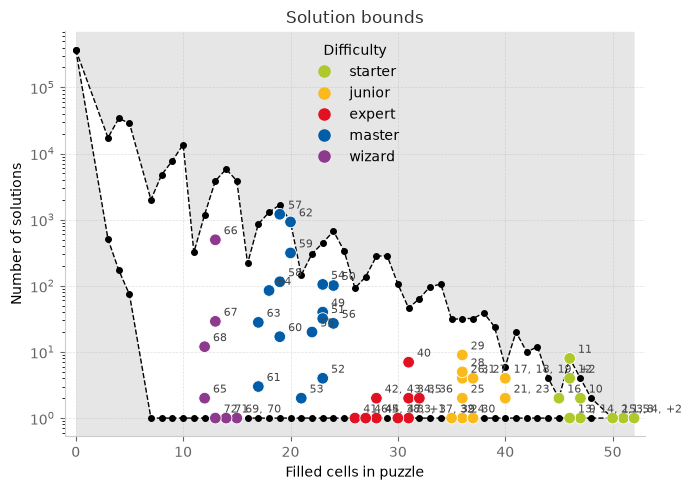

In [7]:
ax = plot_bounds(lower_puzzles, lower_stats, upper_puzzles, upper_stats)
plot_puzzle_stats(main_puzzles, main_stats, ax=ax)
plt.show()

The booklet sits well inside the band. From 7 filled cells on, the lower bound is 1 at every count: there is always a
puzzle with a unique solution. At the other edge, puzzle 62 touches the upper bound: its 925 solutions are the most any
puzzle with 20 filled cells can have.

## 3. How few pieces make a unique puzzle?

The lower bound answers the puzzle designer's question: **what is the fewest number of filled cells that can still pin
down a single solution?**

In [8]:
def by_filled(puzzles, stats):
    # (filled cells, number of solutions, puzzle) for each puzzle, by filled cells
    return sorted(((p.nr_filled_cells, len(stats[name].elapsed), p) for name, p in puzzles.items()), key=lambda e: e[:2])

lower = by_filled(lower_puzzles, lower_stats)
book = by_filled(main_puzzles, main_stats)

fewest_unique = next(entry for entry in lower if entry[1] == 1)
book_fewest_unique = next(entry for entry in book if entry[1] == 1)
print(f"Fewest filled cells for a unique solution: {fewest_unique[0]} (the booklet's fewest: {book_fewest_unique[0]}, puzzle {book_fewest_unique[2].name})")
print(fewest_unique[2].copy(rename=f"with the fewest solutions at {fewest_unique[0]} filled cells"))

Fewest filled cells for a unique solution: 7 (the booklet's fewest: 13, puzzle 72)
Puzzle with the fewest solutions at 7 filled cells

 ┏━━━━━━━━━━━━━━━━━━━━━━┓ 
 ┃A                     ┃ 
 ┃A                     ┃ 
 ┃A A                   ┃ 
 ┃            F F       ┃ 
 ┃              F       ┃ 
 ┗━━━━━━━━━━━━━━━━━━━━━━┛ 

B B   C C   D     E     G G G   H       I I   J   K K     L   
B B   C     D D   E     G       H H       I   J   K K   L L L 
  B   C     D     E E   G         H H   I I   J           L   
      C     D       E                         J               


Two pieces are enough. With just `A` and `F` placed like this, there is exactly one way to fit the other ten, while the
booklet's most open unique puzzle still gives away 13 cells. Anything with fewer filled cells, a single piece or
none, has at least 74 solutions.

# Part II: IQpuzzlerPRO

Part I found that most of IQpuzzler's puzzles have more than one solution: only 29 of the 72 in the booklet are
unique. Its sequel, *IQpuzzlerPRO*, is a revamped version of the game: a new set of 12 pieces, three boards, 120 new
puzzles, and a promise on the box that every one of them has exactly **one** solution.

## 4. New pieces, new boards, same solver

The 11 x 5 rectangle is still there, joined by a diagonal *alt* board and a **pyramid**: 5 layers of 5x5, 4x4, ... 1x1
cells, where pieces can also lie in the pyramid's tilted planes. It is the same pyramid as the original's second
booklet.

In [9]:

for key in ["alt", "pyramid"]:
    board = IQpuzzlerPRO.puzzles[f"empty_{key}"]
    print(board.setup.render(board.grid, header=key))
print(IQpuzzlerPRO.puzzles["empty_main"])

alt

   ┏━━━━━━━━┓         
 ┏━┛        ┃         
 ┃          ┗━━━┓     
 ┃              ┃     
 ┃              ┗━━━┓ 
 ┃                  ┃ 
 ┗━━━┓              ┃ 
     ┃              ┃ 
     ┗━━━┓          ┃ 
         ┃        ┏━┛ 
         ┗━━━━━━━━┛   
pyramid

layer 0         layer 1         layer 2         layer 3         layer 4       
 ┏━━━━━━━━━━┓    ┏━━━━━━━━┓      ┏━━━━━━┓        ┏━━━━┓          ┏━━┓         
 ┃          ┃    ┃        ┃      ┃      ┃        ┃    ┃          ┃  ┃         
 ┃          ┃    ┃        ┃      ┃      ┃        ┃    ┃          ┗━━┛         
 ┃          ┃    ┃        ┃      ┃      ┃        ┗━━━━┛                       
 ┃          ┃    ┃        ┃      ┗━━━━━━┛                                     
 ┃          ┃    ┗━━━━━━━━┛                                                   
 ┗━━━━━━━━━━┛                                                                 
Puzzle empty_main

 ┏━━━━━━━━━━━━━━━━━━━━━━┓ 
 ┃                      ┃ 
 ┃                      ┃ 
 

To the solver these are all the same thing. A board is a set of cells plus how its axes relate (`PyramidBoard` offsets
each layer by half a cell, `RegularBoard` doesn't). The `Setup` turns that geometry into the list of valid placements,
and from then on the search only sees the exact cover table of `1_solver`. Every board here happens to have 55 cells,
but nothing depends on that.

## 5. "Every puzzle has exactly one solution"

That is the promise the original game couldn't make. Let's check it on all three PRO booklets, with the two IQpuzzler
ones for comparison:

In [10]:
books = {
    ("IQpuzzler", "main_puzzles"): IQpuzzler.books["main_puzzles"],
    ("IQpuzzler", "pyramid_puzzles"): IQpuzzler.books["pyramid_puzzles"],
    ("IQpuzzlerPRO", "main_puzzles"): IQpuzzlerPRO.books["main_puzzles"],
    ("IQpuzzlerPRO", "alt_puzzles"): IQpuzzlerPRO.books["alt_puzzles"],
    ("IQpuzzlerPRO", "pyramid_puzzles"): IQpuzzlerPRO.books["pyramid_puzzles"],
}
results = {key: solve_puzzlebook(book) for key, book in books.items()}

print(f"{'game':<14}{'book':<17}{'puzzles':>8}{'unique':>8}   not unique")
for (game, name), (solutions, _) in results.items():
    multiple = {p: len(s) for p, s in solutions.items() if len(s) > 1}
    shown = ", ".join(f"{p}: {n}" for p, n in multiple.items()) if len(multiple) <= 8 else f"{len(multiple)} puzzles"
    print(f"{game:<14}{name:<17}{len(solutions):>8}{len(solutions) - len(multiple):>8}   {shown}")

game          book              puzzles  unique   not unique
IQpuzzler     main_puzzles           72      29   43 puzzles
IQpuzzler     pyramid_puzzles        29      22   85: 2, 89: 2, 92: 2, 95: 2, 98: 2, 100: 6, 101: 3
IQpuzzlerPRO  main_puzzles           40      40   
IQpuzzlerPRO  alt_puzzles            40      40   
IQpuzzlerPRO  pyramid_puzzles        40      39   120: 5


The promise holds on the flat boards: all 80 main and alt puzzles are unique. On the pyramid it holds for 39 of 40,
and **puzzle 120** has 5 solutions:

In [11]:
pro_pyramid = IQpuzzlerPRO.books["pyramid_puzzles"]
pro_pyramid_solutions, pro_pyramid_stats = results[("IQpuzzlerPRO", "pyramid_puzzles")]
print(pro_pyramid["120"])
print(pro_pyramid_solutions["120"])

Puzzle 120

layer 0         layer 1         layer 2         layer 3         layer 4       
 ┏━━━━━━━━━━┓    ┏━━━━━━━━┓      ┏━━━━━━┓        ┏━━━━┓          ┏━━┓         
 ┃          ┃    ┃        ┃      ┃      ┃        ┃    ┃          ┃  ┃         
 ┃      A   ┃    ┃        ┃      ┃      ┃        ┃    ┃          ┗━━┛         
 ┃  A A A A ┃    ┃        ┃      ┃      ┃        ┗━━━━┛                       
 ┃          ┃    ┃        ┃      ┗━━━━━━┛                                     
 ┃          ┃    ┗━━━━━━━━┛                                                   
 ┗━━━━━━━━━━┛                                                                 

  B     C C   D     E     F       G G G   H       I I   J J   K     L L L 
  B B   C     D D   E     F F     G       H         I   J J   K K   L   L 
B B     C       D   E E     F F           H H H         J     K           
        C             E                                                   
Puzzle 120 (solution 1)

layer 0         layer 1       

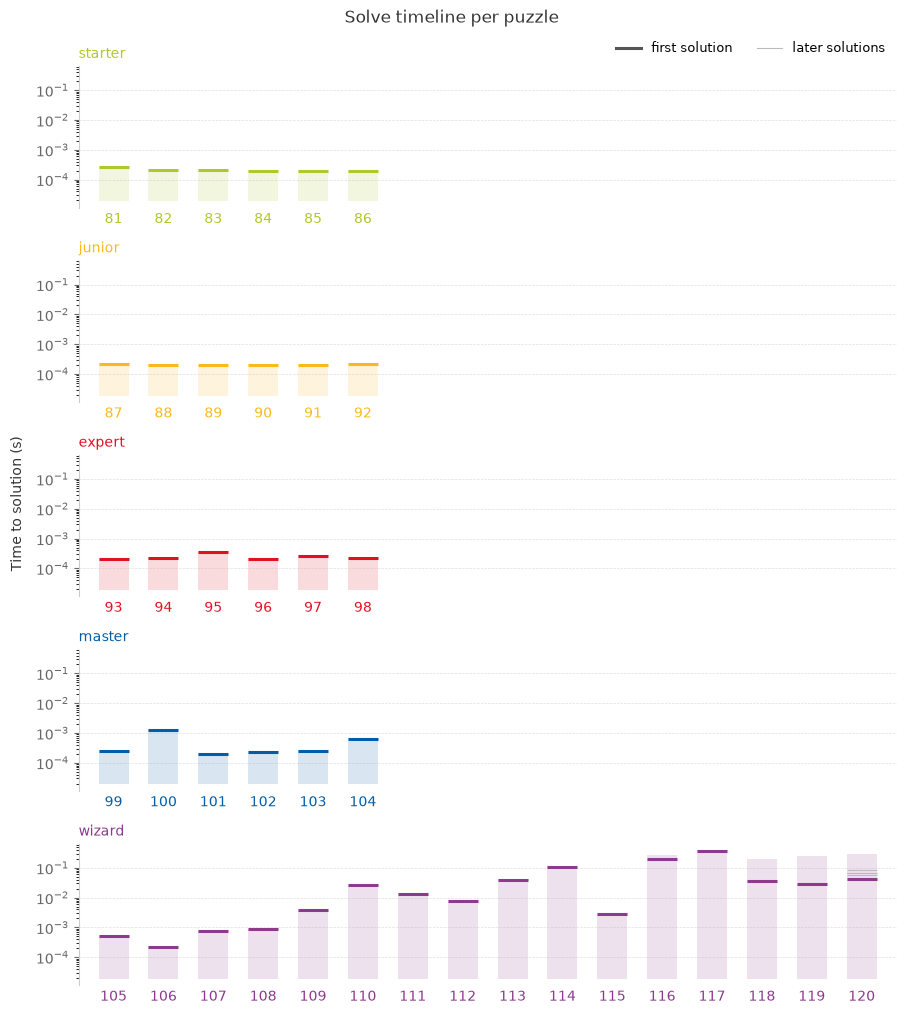

In [12]:
plot_solve_timeline(pro_pyramid, pro_pyramid_stats)
plt.show()

This isn't the solver's mistake. `tests/data/IQpuzzlerPRO/` holds the booklet's printed solution for every PRO
puzzle, entered and checked by hand. `tests/test_solver.py` asserts that the solver finds that solution and no other,
except for pyramid 120, where it finds the printed one and four more. Each of the five can be checked by eye above.

# Summary

- An exact-cover search that always branches on the scarcest cell *or* block finds every solution of every booklet
  puzzle in milliseconds, and of a whole booklet in under a second.
- Only 29 of the original IQpuzzler's 72 booklet puzzles have a unique solution. Master puzzle 57 has 1,209.
- The empty board has 371,020 solutions. From them come exact bounds for every number of filled cells: two pieces
  (7 cells) can already force a unique solution, while the booklet never gives away fewer than 13 cells for one.
  Puzzle 62 is as open as a 20-cell puzzle can be.
- IQpuzzlerPRO keeps its promise on the flat boards, with all 80 puzzles unique. On the pyramid, puzzle 120 has five
  solutions. The original IQpuzzler's pyramid booklet has 7 of 29 non-unique.